In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

conn = sqlite3.connect("../data/processed/sales.db")
print("Połączono z bazą")

Połączono z bazą


CTE — miesięczny trend above/below avg

In [4]:
query_cte = """
    WITH monthly AS (
        SELECT
            strftime('%Y-%m', order_date) AS month,
            ROUND(SUM(sales), 2)          AS total_sales,
            ROUND(SUM(profit), 2)         AS total_profit
        FROM orders
        GROUP BY month
    ),
    avg_profit AS (
        SELECT AVG(total_profit) AS avg_p FROM monthly
    )
    SELECT
        m.month,
        m.total_sales,
        m.total_profit,
        ROUND(a.avg_p, 2) AS avg_profit,
        CASE
            WHEN m.total_profit >= a.avg_p THEN 'Above Average'
            ELSE 'Below Average'
        END AS status
    FROM monthly m, avg_profit a
    ORDER BY m.month
"""
df_cte = pd.read_sql(query_cte, conn)
df_cte

,month,total_sales,total_profit,avg_profit,status
0,2014-01,14236.90,2450.19,5966.61,Below Average
1,2014-02,4519.89,862.31,5966.61,Below Average
2,2014-03,55691.01,498.73,5966.61,Below Average
3,2014-04,28295.35,3488.84,5966.61,Below Average
4,2014-05,23648.29,2738.71,5966.61,Below Average
5,2014-06,34595.13,4976.52,5966.61,Below Average
6,2014-07,33946.39,-841.48,5966.61,Below Average
7,2014-08,27909.47,5318.10,5966.61,Below Average
8,2014-09,81777.35,8328.10,5966.61,Above Average
9,2014-10,31453.39,3448.26,5966.61,Below Average


Wizualizacja

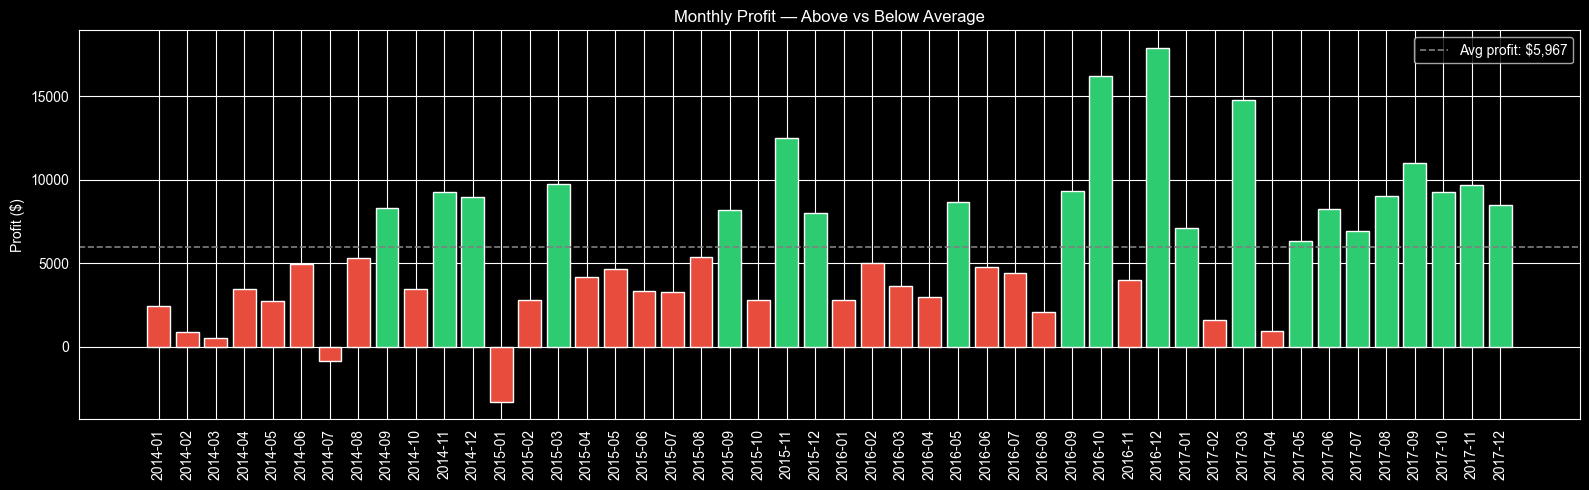

Above average: 21 miesięcy
Below average: 27 miesięcy


In [6]:
colors = df_cte['status'].map({'Above Average': '#2ecc71', 'Below Average': '#e74c3c'})

plt.figure(figsize=(16, 5))
plt.bar(df_cte['month'], df_cte['total_profit'], color=colors)
plt.axhline(df_cte['avg_profit'].iloc[0], color='gray',
            linestyle='--', linewidth=1.2,
            label=f"Avg profit: ${df_cte['avg_profit'].iloc[0]:,.0f}")
plt.xticks(rotation=90)
plt.title("Monthly Profit — Above vs Below Average")
plt.ylabel("Profit ($)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/sql_monthly_profit.png", dpi=150)
plt.show()

# Podsumowanie
above = (df_cte['status'] == 'Above Average').sum()
below = (df_cte['status'] == 'Below Average').sum()
print(f"Above average: {above} miesięcy")
print(f"Below average: {below} miesięcy")

Window Function — ranking klientów per region

In [7]:
query_ranking = """
    SELECT
        customer_name,
        region,
        ROUND(SUM(sales), 2)   AS total_sales,
        ROUND(SUM(profit), 2)  AS total_profit,
        RANK() OVER (
            PARTITION BY region
            ORDER BY SUM(profit) DESC
        ) AS rank_in_region
    FROM orders
    GROUP BY customer_name, region
    ORDER BY region, rank_in_region
"""
df_rank = pd.read_sql(query_ranking, conn)

# Top 3 per region
top3 = df_rank[df_rank['rank_in_region'] <= 3]
top3

,customer_name,region,total_sales,total_profit,rank_in_region
0,Tamara Chand,Central,18437.14,8745.06,1
1,Adrian Barton,Central,12181.59,5362.61,2
2,Sanjit Chand,Central,9900.19,4668.69,3
629,Hunter Lopez,East,10522.55,5045.86,1
630,Tom Ashbrook,East,13723.50,4599.21,2
631,Daniel Raglin,East,6937.87,3050.33,3
1303,Christopher Martinez,South,6682.26,3197.46,1
1304,Sanjit Engle,South,8805.04,2825.29,2
1305,Katrina Willman,South,3747.93,1605.70,3
1815,Raymond Buch,West,14345.28,6807.09,1


Discount Impact

In [11]:
query_discount = """
    SELECT
        CASE
            WHEN discount = 0    THEN '1. No Discount'
            WHEN discount <= 0.2 THEN '2. Low (1-20%)'
            WHEN discount <= 0.4 THEN '3. Mid (21-40%)'
            ELSE                      '4. High (40%+)'
        END AS discount_bucket,
        COUNT(*)                                    AS orders,
        ROUND(AVG(profit), 2)                       AS avg_profit,
        ROUND(AVG(sales), 2)                        AS avg_sales,
        ROUND(100.0 * SUM(profit) / SUM(sales), 2) AS profit_margin_pct
    FROM orders
    GROUP BY discount_bucket
    ORDER BY discount_bucket
"""
df_disc = pd.read_sql(query_discount, conn)
df_disc

,discount_bucket,orders,avg_profit,avg_sales,profit_margin_pct
0,1. No Discount,4798,66.90,226.74,29.51
1,2. Low (1-20%),3803,26.50,222.59,11.91
2,3. Mid (21-40%),460,-77.86,509.00,-15.30
3,4. High (40%+),933,-106.71,137.87,-77.40


In [12]:
high_disc_loss = df_disc[df_disc['discount_bucket'] == '4. High (40%+)']['avg_profit'].values[0]
high_disc_orders = df_disc[df_disc['discount_bucket'] == '4. High (40%+)']['orders'].values[0]
print(f"Szacowana strata z High Discount: ${abs(high_disc_loss * high_disc_orders):,.0f}")

Szacowana strata z High Discount: $99,560


Wizualizacja

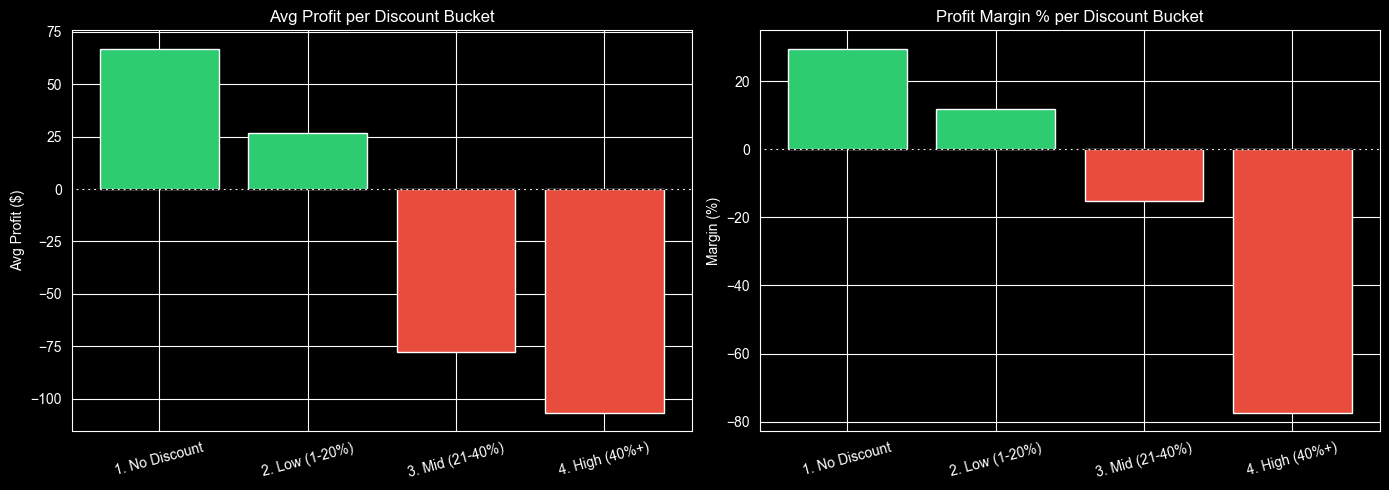

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_disc['avg_profit']]

axes[0].bar(df_disc['discount_bucket'], df_disc['avg_profit'], color=colors)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title("Avg Profit per Discount Bucket")
axes[0].set_ylabel("Avg Profit ($)")
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(df_disc['discount_bucket'], df_disc['profit_margin_pct'], color=colors)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title("Profit Margin % per Discount Bucket")
axes[1].set_ylabel("Margin (%)")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("../data/processed/sql_discount_impact.png", dpi=150)
plt.show()

Zamknięcie połączenia

In [14]:
conn.close()
print("Połączenie zamknięte")

Połączenie zamknięte
